# M4-B1 — Benchmark Mistral Assurances

> Concevoir une IA simple : benchmark 3+ familles de modèles + grille
> de décision. Référence baseline : `mistral-tarif-v1` (R² 0.39).

Auteur·rice : `<prénom>` — Date : `<date>`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append('../src')

RANDOM_STATE = 42
DATA_PATH = Path('../data/bike_sharing.csv')
sns.set_theme(style='whitegrid')

## 1. Reprise baseline mistral-tarif-v1 (~30 min)

Charge le modèle baseline depuis le repo `mistral-tarif-v1`, note ses
métriques rapportées (R² 0.39, MAE 105, RMSE 139), identifie les angles
morts du code 2024 (cf. mini-cours 04 méthodologie benchmark).

In [9]:
# Étape 1 — charger le baseline mistral-tarif-v1.
# Prérequis : cloner le repo baseline EN VOISIN de ton repo M4-B1
# (dans le dossier PARENT, pour que le chemin ../../ ci-dessous fonctionne) :
#   git clone https://github.com/Formation-SIMPLON-IA/mistral-tarif-v1.git
import joblib

# suppose le baseline cloné en voisin de ton repo M4-B1
model_v1 = joblib.load("../models/mistral_tarif_v1.joblib")
model_v1


LinearRegression()

## 2. EDA orientée saisonnalité (~1h30)

Au moins **4 visualisations Seaborn** : boxplot par saison, courbe par
heure-moyenne, scatter température vs cnt, corrélations.

> *« Quelle saisonnalité je vois ? Comment elle explique la
> sous-performance de la baseline ? »*

In [10]:
df = pd.read_csv(DATA_PATH)
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      17379 non-null  int64  
 1   date                    17379 non-null  object 
 2   season                  17379 non-null  object 
 3   year                    17379 non-null  int64  
 4   month                   17379 non-null  int64  
 5   hour                    17379 non-null  int64  
 6   is_holiday              17379 non-null  int64  
 7   weekday                 17379 non-null  int64  
 8   is_working_day          17379 non-null  int64  
 9   weather                 17379 non-null  int64  
 10  temperature_norm        17379 non-null  float64
 11  temperature_feels_norm  17379 non-null  float64
 12  humidity_norm           17379 non-null  float64
 13  windspeed_norm          17379 non-null  float64
 14  casual_riders           17379 non-null

,id,date,season,year,month,hour,is_holiday,weekday,is_working_day,weather,temperature_norm,temperature_feels_norm,humidity_norm,windspeed_norm,casual_riders,registered_riders,total_rentals
0,1,2011-01-01,winter,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,winter,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,winter,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


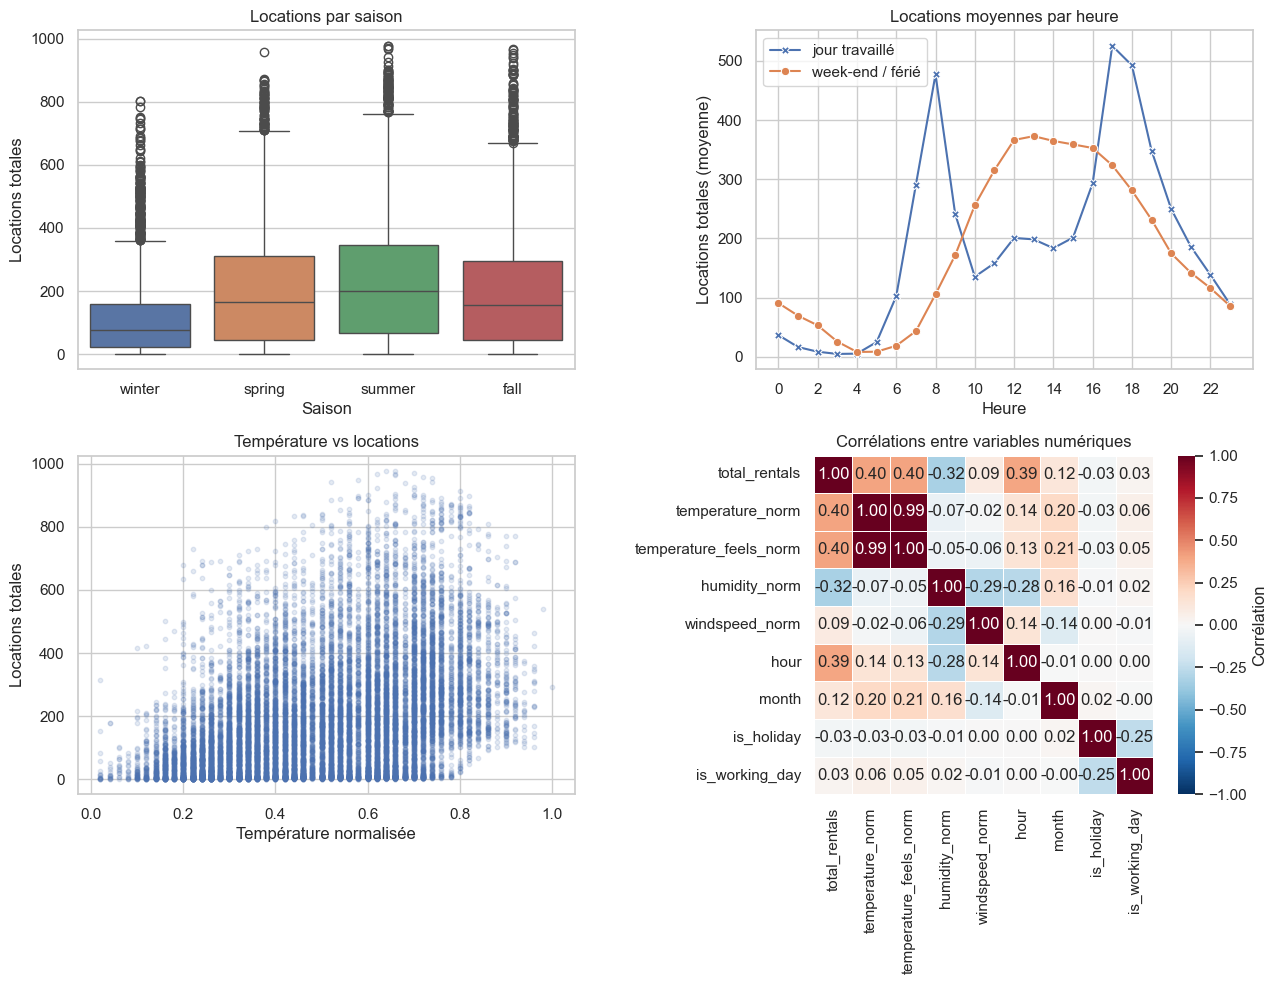

In [11]:
# 4 visualisations EDA — boxplot par saison, courbe par heure-moyenne,
# scatter température vs cnt, heatmap corrélations.
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Boxplot par saison
season_order = ["winter", "spring", "summer", "fall"]
sns.boxplot(data=df, x="season", y="total_rentals", order=season_order,
            hue="season", palette="deep", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Locations par saison")
axes[0, 0].set_xlabel("Saison")
axes[0, 0].set_ylabel("Locations totales")

# 2. Courbe heure -> moyenne des locations, séparée jour travaillé vs
# week-end/férié (is_holiday => is_working_day=0, donc "week-end / férié"
# couvre bien les deux cas sans les compter deux fois).
df_hour = df.assign(
    jour_type=np.where(df["is_working_day"] == 1, "jour travaillé", "week-end / férié")
)
sns.lineplot(data=df_hour, x="hour", y="total_rentals", hue="jour_type",
             hue_order=["jour travaillé", "week-end / férié"],
             style="jour_type", markers=True, dashes=False,
             palette="deep", errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title("Locations moyennes par heure")
axes[0, 1].set_xlabel("Heure")
axes[0, 1].set_ylabel("Locations totales (moyenne)")
axes[0, 1].set_xticks(range(0, 24, 2))
axes[0, 1].legend(title=None)

# 3. Scatter température vs locations (alpha réduit : 17k points)
axes[1, 0].scatter(df["temperature_norm"], df["total_rentals"],
                    alpha=0.15, s=10, color=sns.color_palette("deep")[0])
axes[1, 0].set_title("Température vs locations")
axes[1, 0].set_xlabel("Température normalisée")
axes[1, 0].set_ylabel("Locations totales")

# 4. Heatmap des corrélations — colormap divergente centrée sur 0
num_cols = ["total_rentals", "temperature_norm", "temperature_feels_norm",
            "humidity_norm", "windspeed_norm", "hour", "month",
            "is_holiday", "is_working_day"]
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True,
            fmt=".2f", square=True, linewidths=0.5, ax=axes[1, 1],
            cbar_kws={"label": "Corrélation"})
axes[1, 1].set_title("Corrélations entre variables numériques")

fig.tight_layout()
plt.close(fig)  # évite le double affichage (backend inline + retour de cellule)
fig


### Conclusion de l'EDA

- **Variables les plus importantes** : `hour` (pics bimodaux à 8h et 17-18h, corr. linéaire faible ~0.39 car la relation n'est pas monotone), `temperature_norm`/`temperature_feels_norm` (corr. ~0.40 mais quasi colinéaires entre elles, r=0.99) et `season` (été 236 loc/h en moyenne vs hiver 111, soit ×2.1), `humidity_norm` en négatif (-0.32).
- **Pourquoi la baseline linéaire est limitée** : la corrélation max avec `total_rentals` plafonne à ~0.40 en linéaire alors que `hour` et `season` ont un effet fort mais **non-monotone/catégoriel** (deux pics horaires, 4 régimes saisonniers) — une régression linéaire sans feature engineering (cyclique/one-hot) ne peut pas capturer ces ruptures, d'où le R² 0.39 rapporté.
- **Famille attendue gagnante** : Gradient Boosting (`HistGradientBoostingRegressor`), car il capture nativement les interactions (heure × saison × météo) et les seuils non-linéaires sans encodage manuel ; RandomForest devrait suivre de près, la régression linéaire restant en retrait sauf si on ajoute l'encodage cyclique de `hour`/`month`.

## 3. Split argumenté + validation croisée (~30 min)

Choisir **`TimeSeriesSplit`** ou **`KFold` stratifié** — justifier.

Mini-cours 02 (split temporel vs stratifié) à consulter.

> 🎓 **Réflexe anti-fuite (la leçon de M2-B1, enfin mise en œuvre).** En M2-B1 tu
> as construit un `Pipeline` sans modèle ni split : la fuite ne pouvait pas se
> produire. Ici tu as **un split ET un modèle** → la règle s'applique : un
> préprocesseur **qui apprend des paramètres** (`StandardScaler`, `SimpleImputer`)
> ne se `fit` **jamais** sur l'ensemble des données. On l'enferme dans le
> `Pipeline` du modèle, et c'est **ce Pipeline** qu'on passe à la validation
> croisée — scikit-learn re-`fit` alors le scaler sur les seuls folds
> d'entraînement. Sinon : fuite → R² **optimiste mensonger**. On le démontre
> juste en dessous.

In [12]:
from sklearn.model_selection import TimeSeriesSplit

# Choix : TimeSeriesSplit (pas de KFold, même stratifié).
# Le dataset est chronologiquement trié (2011-01-01 -> 2012-12-31, vérifié
# monotone croissant) : les observations sont autocorrélées dans le temps
# (saisonnalité, tendance), donc pas i.i.d. Un KFold classique mélangerait
# passé et futur dans les folds -> fuite temporelle (le modèle "verrait"
# des données futures pour prédire le passé), un scénario irréaliste en
# production puisqu'on ne dispose jamais du futur au moment de prédire.
# TimeSeriesSplit entraîne toujours sur une fenêtre passée et teste sur la
# fenêtre future qui suit -> reproduit les conditions réelles de déploiement.
#
# Réutilisé tel quel en section 4 (benchmark) — cf. règle d'or du même splitter
# pour tous les modèles comparés.
N_SPLITS = 5
SPLITTER = TimeSeriesSplit(n_splits=N_SPLITS)
SPLITTER


TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

### 🔬 Fuites de données — démonstration (à faire une fois)

La cellule compare **trois** situations en validation croisée (Ridge) :
la **fuite de cible** (`casual_riders`/`registered_riders` dans X — ils
somment la cible), la **fuite de prétraitement** (`StandardScaler` fitté sur
**tout** X avant la CV) et la version **propre** (scaler dans le `Pipeline`).

> **À rédiger après exécution** (2-3 phrases, → journal de bord) : la fuite de
> cible crève l'écran (R² ≈ 1.0) ; la fuite de prétraitement est **quasi
> invisible ici** (~±0.0005 sur 17k lignes, parfois même légèrement négative —
> c'est du bruit). Explique *dans quel cas* elle exploserait (peu de données,
> imputation moyenne/médiane, encodage supervisé) — et donc pourquoi on
> encapsule le prétraitement **par défaut** : cette fuite-là ne prévient pas.


In [13]:
# 🔬 Démonstration fuites vs propre (Ridge) — à exécuter une fois le
# preprocessing complété (FEATURES rempli dans preprocess.py).
# Cellule pré-écrite : tu n'as pas à la coder, juste à la faire tourner.
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from preprocess import load_dataset

try:
    X_demo, y_demo = load_dataset(DATA_PATH)   # SANS casual_riders / registered_riders
    df_full = pd.read_csv(DATA_PATH)
    splitter_demo = TimeSeriesSplit(n_splits=5)
    pipe = lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0))

    # (0) FUITE DE CIBLE : les composantes de y remises dans X
    X_cible = X_demo.assign(casual_riders=df_full["casual_riders"],
                            registered_riders=df_full["registered_riders"])
    r2_cible = cross_val_score(pipe(), X_cible, y_demo, cv=splitter_demo, scoring="r2").mean()

    # (1) FUITE DE PRÉTRAITEMENT : le scaler est fitté sur TOUT X, avant la CV
    X_leak = StandardScaler().fit_transform(X_demo)
    r2_leak = cross_val_score(Ridge(alpha=1.0), X_leak, y_demo, cv=splitter_demo, scoring="r2").mean()

    # (2) PROPRE : le scaler vit DANS le pipeline -> re-fitté sur chaque fold d'entraînement
    r2_clean = cross_val_score(pipe(), X_demo, y_demo, cv=splitter_demo, scoring="r2").mean()

    display(pd.DataFrame(
        {"R² moyen (CV)": [round(r2_cible, 4), round(r2_leak, 4), round(r2_clean, 4)],
         "écart vs propre": [format(r2_cible - r2_clean, "+.4f"),
                             format(r2_leak - r2_clean, "+.5f"), "—"]},
        index=["fuite de CIBLE (riders dans X)",
               "fuite de PRÉTRAITEMENT (scaler global)",
               "propre (scaler dans le pipeline)"],
    ))
except Exception as e:
    print(f"⏳ Démo à relancer une fois preprocess.load_dataset opérationnel (FEATURES rempli). Détail : {e}")


,R² moyen (CV),écart vs propre
fuite de CIBLE (riders dans X),1.0000,+0.7483
fuite de PRÉTRAITEMENT (scaler global),0.2533,+0.00152
propre (scaler dans le pipeline),0.2517,—


## 4. Benchmark — 3 familles minimum (~2h)

**Famille A** — Linéaire (Ridge ou variante)  
**Famille B** — Arbre / RandomForest  
**Famille C** — Gradient Boosting (HistGradientBoostingRegressor)

Pour chaque modèle :
- Mêmes folds, mêmes métriques
- MAE, RMSE, R²
- Temps train, latence inférence
- Persistance `.joblib` dans `models/`

> ⚠️ **Règle d'or** : réutilise **exactement le même splitter** que la section 3 (Split). Un splitter différent d'un modèle à l'autre = comparaison invalide.


In [14]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.pipeline import make_pipeline

from preprocess import load_dataset, add_cyclic_features
from train_models import run_benchmark

X, y = load_dataset(DATA_PATH)


def _cyclic_then_drop(X_raw: pd.DataFrame) -> pd.DataFrame:
    """hour/month -> sin/cos, puis on retire les versions brutes (redondantes)."""
    X_cyc = add_cyclic_features(X_raw)
    return X_cyc.drop(columns=["hour", "month"])


# Famille A — Linéaire (Ridge) : encodage cyclique + StandardScaler, tout DANS
# la factory -> run_benchmark les re-fit sur chaque fold d'entraînement (anti-fuite).
def make_linear():
    return make_pipeline(
        FunctionTransformer(_cyclic_then_drop),
        StandardScaler(),
        Ridge(alpha=1.0, random_state=RANDOM_STATE),
    )


# Famille B — Arbre / RandomForest : pas de scaling, gère nativement les
# seuils non-linéaires (heure, saison) sans feature engineering.
# max_depth/min_samples_leaf bornés : des arbres non élagués sur 17k lignes
# produisent un .joblib de ~300 Mo pour un gain de R² négligeable.
def make_random_forest():
    return RandomForestRegressor(
        n_estimators=200, max_depth=18, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1,
    )


# Famille C — Gradient Boosting : idem, pas de scaling nécessaire.
def make_gradient_boosting():
    return HistGradientBoostingRegressor(random_state=RANDOM_STATE)


MODELS = {
    "Ridge (linéaire)": make_linear,
    "RandomForest": make_random_forest,
    "HistGradientBoosting": make_gradient_boosting,
}

# Même splitter que la section 3 (règle d'or de comparabilité)
benchmark_summary = run_benchmark(MODELS, X, y, SPLITTER)
benchmark_summary


KeyError: "['month'] not found in axis"

In [ ]:
# Persistance .joblib dans models/ — entraînement final sur l'ENSEMBLE des
# données (la CV ci-dessus sert uniquement à évaluer ; l'artefact déployé,
# lui, exploite tout l'historique disponible).
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

for name, factory in MODELS.items():
    slug = name.lower().split(" ")[0]  # "ridge", "randomforest", "histgradientboosting"
    final_model = factory()
    final_model.fit(X, y)
    joblib.dump(final_model, MODELS_DIR / f"mistral_tarif_v2_{slug}.joblib")

sorted(p.name for p in MODELS_DIR.glob("mistral_tarif_v2_*.joblib"))


['mistral_tarif_v2_histgradientboosting.joblib',
 'mistral_tarif_v2_randomforest.joblib',
 'mistral_tarif_v2_ridge.joblib']

## 5. Tableau comparatif (~30 min, mercredi)

Remplis `benchmark_table.md` avec les chiffres + interprétation pour
Inès Tabet (lisible actuaire, pas data scientist).

## 6. Verdict + decision card (~30 min, mercredi)

- `verdict.md` : 5 lignes max, recommandation chiffrée
- `decision_card.md` : ta version perso de la grille de décision C4
  (à confronter à la collective)

## 7. Restitution + grille collective (mercredi 11h30-12h45)

**Geste pédagogique central** — co-construction de la grille de
décision C4 sur Excalidraw partagé.

Archivée ensuite dans `ressources-publiques/grille_decision_C4.md`.